# Kuromi vs Cinnamoroll - Clasificador Binario con Transfer Learning

**Diplomado Superior en Redes Neuronales Artificiales y Deep Learning (UAEM)**  
**Modulo 4: Deep Learning | Proyecto: Kuromi_vs_Cinnamoroll**

---

## Objetivo

Construir un **clasificador binario** capaz de distinguir entre figuras de **Kuromi y Cinnamoroll** (personajes Sanrio) usando **Transfer Learning** con **ResNet18**.

## Metodologia

| Paso | Descripcion |
|------|-------------|
| 1 | Dataset: fotos de tus figuras + scraping web |
| 2 | Data Augmentation: rotaciones, volteos, ajustes de color |
| 3 | Transfer Learning: ResNet18 pre-entrenada en ImageNet |
| 4 | Fine-tuning: entrenar cabeza clasificadora + descongelar capas |
| 5 | Evaluacion: accuracy, matriz de confusion, ROC curve |
| 6 | Inferencia: probar con fotos nuevas |

## Dataset

```
dataset/
  train/
    kuromi/     (150+ imagenes)
    cinnamon/   (150+ imagenes)
  test/
    kuromi/     (30+ imagenes)
    cinnamon/   (30+ imagenes)
```

## Dependencias

- Python 3.8+
- PyTorch >= 1.9 + torchvision
- matplotlib + numpy + Pillow
- scikit-learn
- seaborn

---
## 1. Configuracion inicial

Deteccion automatica de plataforma (Colab / VSCode) y configuracion de rutas.


In [1]:
# ---
# 1. CONFIGURACION INICIAL - IMPORTS + PLATAFORMA
# ---
import os, sys, io, warnings, copy, time, json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

warnings.filterwarnings('ignore')

# Deteccion de plataforma
EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    print('Plataforma: Google Colab')
    from google.colab import files
    from google.colab import drive
    drive.mount('/content/drive')

    RUTA_BASE = '/content/drive/MyDrive/Diplomado/Modulo4/Proyectos/Kuromi_vs_Cinnamoroll'
    RUTA_DATASET = RUTA_BASE + '/dataset'
    RUTA_MODELOS = RUTA_BASE + '/modelos'
else:
    print('Plataforma: Local (VSCode / Jupyter)')
    RUTA_BASE = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
    RUTA_DATASET = os.path.join(RUTA_BASE, 'dataset')
    RUTA_MODELOS = os.path.join(RUTA_BASE, 'modelos')

os.makedirs(RUTA_MODELOS, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo: ' + str(device))
print('Dataset: ' + RUTA_DATASET)

# --- Autoria y timer (se usa en el footer) ---
AUTORA = "Diana Blanco - MorritaConP1to"
INICIO = time.time()

# --- CONFIG: hiperparametros globales ---
CONFIG = {
    'BATCH_SIZE': 16,
    'EPOCHS_FASE1': 10,
    'EPOCHS_FASE2': 15,
    'LR_FASE1': 0.001,
    'LR_FASE2': 0.0001,
    'IMG_SIZE': 224,
    'NUM_CLASES': 2,
    'PACIENTIA_EARLY': 5,
    'DROPOUT': 0.3,
    'AUTORA': AUTORA,
}
print('CONFIG:', CONFIG)

Plataforma: Local (VSCode / Jupyter)
Dispositivo: cuda
Dataset: D:\Diplomado-RNA\Modulo-4\Proyectos\Kuromi_vs_Cinnamoroll\dataset
CONFIG: {'BATCH_SIZE': 16, 'EPOCHS_FASE1': 10, 'EPOCHS_FASE2': 15, 'LR_FASE1': 0.001, 'LR_FASE2': 0.0001, 'IMG_SIZE': 224, 'NUM_CLASES': 2, 'PACIENTIA_EARLY': 5, 'DROPOUT': 0.3, 'AUTORA': 'Diana Blanco - MorritaConP1to'}


---
## 2. Data Augmentation y Carga del Dataset

### Por que Data Augmentation?
Con ~150 imagenes por clase, es dificil que una CNN aprenda a generalizar bien.  
La aumentacion de datos genera **variaciones sinteticas** de cada imagen:
- **Volteo horizontal**: el personaje puede estar viendo a cualquier lado.
- **Rotacion**: las fotos pueden tener inclinacion.
- **Color Jitter**: las fotos tienen diferente iluminacion.
- **Zoom aleatorio**: las figuras pueden estar mas cerca o mas lejos.

### Normalizacion
Usamos la media y desviacion estandar de **ImageNet** (con el que ResNet18 fue entrenada). Esto asegura que los valores de entrada esten en el rango que la red espera.


In [2]:
# ---
# 2. DATA AUGMENTATION Y CARGA DEL DATASET
# ---

# Transformaciones para entrenamiento (con aumentacion)
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones para prueba (sin aumentacion, solo resize + normalizar)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Cargar datasets con ImageFolder (mapea subcarpetas a clases)
# Las clases se asignan en orden alfabetico: cinnamon=0, kuromi=1
train_dataset = ImageFolder(root=os.path.join(RUTA_DATASET, 'train'), transform=transform_train)
test_dataset  = ImageFolder(root=os.path.join(RUTA_DATASET, 'test'), transform=transform_test)

# DataLoaders
BATCH_SIZE = 16  # Batch pequeno por memoria GPU
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Informacion del dataset
clases = train_dataset.classes
print('Clases detectadas: ' + str(clases))
print('  Mapeo: ' + str(train_dataset.class_to_idx))
print('  Train: ' + str(len(train_dataset)) + ' imagenes')
print('  Test:  ' + str(len(test_dataset)) + ' imagenes')

Clases detectadas: ['cinnamon', 'kuromi']
  Mapeo: {'cinnamon': 0, 'kuromi': 1}
  Train: 941 imagenes
  Test:  237 imagenes


---
## 3. Visualizacion de Muestras

Veamos algunas imagenes del dataset con sus etiquetas para confirmar que la carga fue correcta.


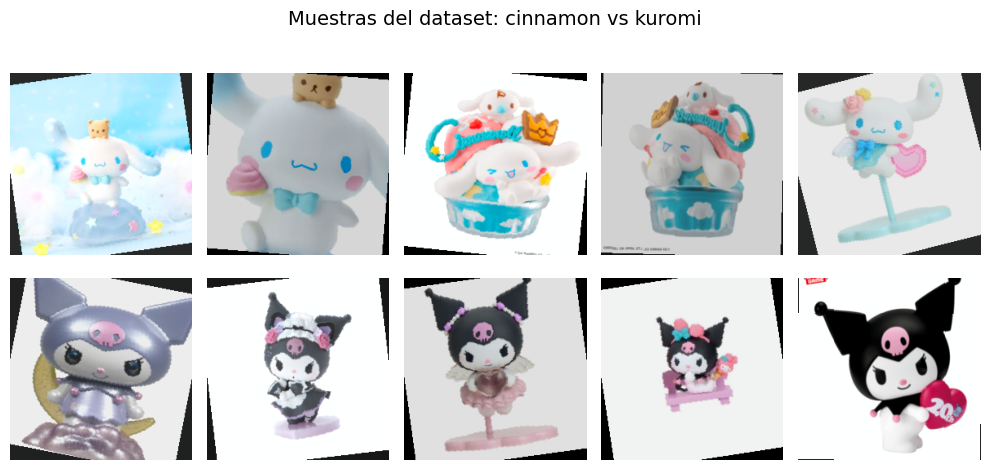

In [3]:
# ---
# 3. VISUALIZACION DE MUESTRAS DEL DATASET
# ---
def mostrar_muestras(dataset, clases, num_por_clase=5):
    '''
    Muestra ejemplos de cada clase del dataset.

    Args:
        dataset: ImageFolder dataset.
        clases: Lista de nombres de clases.
        num_por_clase: Cuantas imagenes mostrar por clase.
    '''
    fig, axes = plt.subplots(len(clases), num_por_clase,
                             figsize=(num_por_clase * 2, len(clases) * 2.5))
    if len(clases) == 1:
        axes = axes.reshape(1, -1)

    for idx_clase, clase in enumerate(clases):
        # Encontrar indices de esta clase
        indices = [i for i, (_, label) in enumerate(dataset) if label == idx_clase]
        indices = indices[:num_por_clase]

        for j, idx in enumerate(indices):
            img, _ = dataset[idx]
            # Desnormalizar para visualizar
            img = img.numpy().transpose(1, 2, 0)
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = img * std + mean
            img = np.clip(img, 0, 1)

            axes[idx_clase, j].imshow(img)
            axes[idx_clase, j].axis('off')
            if j == 0:
                axes[idx_clase, j].set_ylabel(clase, fontsize=12, fontweight='bold')

    plt.suptitle('Muestras del dataset: ' + ' vs '.join(clases), fontsize=14)
    plt.tight_layout()
    plt.show()


mostrar_muestras(train_dataset, clases)

---
## 4. Guia para tomar fotos del dataset

### ?Cuantas fotos por figura?

| Tipo | Fotos sugeridas |
|------|----------------|
| Figura individual | 8-12 fotos (distintos angulos) |
| Legos / versiones mini | 6-8 fotos |
| Mega figura / peluche | 10-15 fotos (acercamientos + cuerpo) |
| Llaveros / accesorios | 4-6 fotos |

### ?Como deben ser las fotos?

| Hacer | Evitar |
|------|--------|
| Fondo liso (pared, mantel) | Fondo saturado de patrones |
| Buena luz natural o artificial | Sombra dura o contraluz |
| Figura centrada, ~70% del encuadre | Figura muy pequena o recortada |
| Variar angulos (frente, perfil, 3/4, picado) | Todas desde el mismo angulo |
| Variar fondos de colores distintos | Siempre el mismo fondo |
| Incluir acompanantes (otras figuras, objetos) | Siempre sola y aislada |

### Organizacion

Las fotos se colocan en las carpetas correspondientes:
- `dataset/train/kuromi/` -> fotos de entrenamiento de Kuromi
- `dataset/train/cinnamon/` -> fotos de entrenamiento de Cinnamoroll
- `dataset/test/kuromi/` -> fotos para evaluar (20-30)
- `dataset/test/cinnamon/` -> fotos para evaluar (20-30)

> **Los nombres de archivo NO importan.** La etiqueta la da la carpeta donde esta.
> Pon 80% en train y 20% en test. Mas detalles en `dataset/guia_fotos.md`.


---
## 5. Buenas Practicas con Datasets de Imagenes

### ?Por que pre-procesar las imagenes?

El DataLoader de PyTorch ya redimensiona a 224x224 y normaliza los pixeles,
pero hay cosas que conviene hacer **antes** de entrenar:

| Problema | Consecuencia | Solucion |
|----------|-------------|----------|
| Imagen corrupta | DataLoader truena a media epoca | Validar con PIL |
| Formato WebP/GIF/BMP | PIL no siempre lo soporta | Convertir a JPEG |
| Archivo < 5 KB | Thumbnail o descarga fallida | Eliminar |
| Fuera de contexto | El modelo aprende ruido | Limpieza manual |

### Flujo recomendado para el dataset

```
Scraping / Fotos
      |
      v
Limpieza manual (borrar lo que no sea Kuromi o Cinnamoroll)
      |
      v
preprocesar_dataset.py (valida, convierte a JPEG, elimina corruptas)
      |
      v
split_dataset.py (80% train, 20% test)
      |
      v
DataLoader + Data Augmentation (dentro del notebook)
      |
      v
Entrenamiento con ResNet18
```

### Buenas practicas adicionales

- **Balance de clases:** procura que ambas clases tengan similar numero de imagenes
- **Variedad:** fondos, angulos e iluminacion distintos evitan overfitting
- **Separacion por figura fisica:** si tienes 3 figuras de Kuromi, pon 2 en train y 1 en test
- **No duplicar:** revisa que no haya imagenes repetidas entre train y test
- **Imagenes web + fotos reales:** mezclar ambas mejora la generalizacion

> Los scripts `preprocesar_dataset.py` y `split_dataset.py` estan en la carpeta `scraping/`.


---
## 6. Transfer Learning con ResNet18

### Que es Transfer Learning?
En lugar de entrenar una red desde cero (lo cual requiere millones de imagenes y mucho tiempo), tomamos una red que ya fue entrenada en **ImageNet** (1.2M imagenes, 1000 clases) y la adaptamos a nuestro problema.

### Estrategia de fine-tuning en 2 fases:

**Fase 1 (Congelado):**
- Congelamos todas las capas convolucionales de ResNet18.
- Solo entrenamos la nueva cabeza clasificadora (capa FC).
- Esto permite que la cabeza aprenda a interpretar los features de ImageNet para nuestras clases.

**Fase 2 (Descongelado):**
- Descongelamos las ultimas capas (layer4).
- Entrenamos toda la red con una tasa de aprendizaje mucho menor.
- Esto ajusta los features de alto nivel especificamente a Kuromi y Cinnamoroll.

### Arquitectura ResNet18 adaptada

```
[Imagen 224x224x3]
       |
[ResNet18 (sin cabeza)]  <- Capas convolucionales pre-entrenadas (congeladas)
       |
[AdaptiveAvgPool2d]      <- Pooling global a 512 features
       |
[Dropout(0.3)]           <- Regularizacion
       |
[FC(512 -> 2)]           <- Nueva cabeza clasificadora (2 clases)
       |
[Logits: Kuromi / Cinnamoroll]
```


In [4]:
# ---
# 4. TRANSFER LEARNING CON RESNET18
# ---
def crear_modelo_transfer_learning(num_clases=2, congelar=True):
    '''
    Crea un modelo ResNet18 adaptado para clasificacion binaria.

    Args:
        num_clases: Numero de clases a clasificar (default 2).
        congelar: Si True, congela todas las capas excepto la cabeza.

    Returns:
        nn.Module: Modelo listo para entrenar.

    Ejemplo:
        modelo = crear_modelo_transfer_learning(num_clases=2, congelar=True)
    '''
    # Cargar ResNet18 pre-entrenada en ImageNet
    modelo = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Congelar todas las capas (opcional)
    if congelar:
        for param in modelo.parameters():
            param.requires_grad = False

    # Obtener numero de features de la ultima capa
    num_features = modelo.fc.in_features

    # Reemplazar la cabeza clasificadora
    modelo.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_clases)
    )

    return modelo


# Crear modelo (fase 1: congelado)
model = crear_modelo_transfer_learning(num_clases=2, congelar=True)
model = model.to(device)

# Contar parametros
total = sum(p.numel() for p in model.parameters())
entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Modelo ResNet18 creado')
print('  Parametros totales: ' + str(total))
print('  Parametros entrenables (cabeza): ' + str(entrenables))

Modelo ResNet18 creado
  Parametros totales: 11308354
  Parametros entrenables (cabeza): 131842


---
## 7. Configuracion del Entrenamiento

| Parametro | Fase 1 (Cabeza) | Fase 2 (Fine-tuning) |
|-----------|-----------------|---------------------|
| Capas entrenables | Solo FC nueva | FC + layer4 |
| Learning Rate | 0.001 | 0.0001 (10x menor) |
| Optimizer | Adam | Adam |
| Epocas | 10 | 15 |
| Loss | CrossEntropyLoss | CrossEntropyLoss |

### Early Stopping
Si la perdida de validacion no mejora en 5 epocas, detenemos el entrenamiento.


In [5]:
# ---
# 5. FUNCION DE PERDIDA, OPTIMIZADOR Y ENTRENAMIENTO
# ---
criterion = nn.CrossEntropyLoss()

# Fase 1: Solo entrenar la cabeza clasificadora
optimizer_fase1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

scheduler_fase1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase1, mode='min', factor=0.5, patience=3
)

print('Fase 1 lista: solo cabeza clasificadora (lr=0.001)')
print('Fase 2 (despues): fine-tuning capas superiores (lr=0.0001)')

Fase 1 lista: solo cabeza clasificadora (lr=0.001)
Fase 2 (despues): fine-tuning capas superiores (lr=0.0001)


---
## 8. Funcion de Entrenamiento

Bucle generico que funciona para ambas fases. Recibe el optimizador y scheduler como parametros para poder reutilizarlo.


In [6]:
# ---
# 6. BUCLE DE ENTRENAMIENTO (REUTILIZABLE)
# ---
def entrenar_biclase(modelo, train_loader, test_loader, criterion,
                     optimizer, scheduler, num_epochs, device,
                     nombre_fase='Fase'):
    '''
    Entrena el modelo y evalua en test al final de cada epoca.

    Args:
        modelo: Modelo ResNet18 adaptado.
        train_loader: DataLoader de entrenamiento.
        test_loader: DataLoader de prueba.
        criterion: CrossEntropyLoss.
        optimizer: Optimizador (Adam).
        scheduler: ReduceLROnPlateau.
        num_epochs: Epocas a entrenar.
        device: CPU/GPU.
        nombre_fase: Nombre para mostrar en logs.

    Returns:
        dict: Historial con train_loss, test_loss, test_acc.
    '''
    historial = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    mejor_loss = float('inf')

    for epoch in range(num_epochs):
        # ---- Entrenamiento ----
        modelo.train()
        train_loss = 0.0

        for imagenes, etiquetas in train_loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

            optimizer.zero_grad()
            predicciones = modelo(imagenes)
            loss = criterion(predicciones, etiquetas)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        historial['train_loss'].append(train_loss)

        # ---- Evaluacion en test ----
        modelo.eval()
        test_loss = 0.0
        correctos = 0
        total = 0

        with torch.no_grad():
            for imagenes, etiquetas in test_loader:
                imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
                outputs = modelo(imagenes)
                loss = criterion(outputs, etiquetas)
                test_loss += loss.item()

                _, predichos = torch.max(outputs, 1)
                total += etiquetas.size(0)
                correctos += (predichos == etiquetas).sum().item()

        test_loss /= len(test_loader)
        accuracy = 100.0 * correctos / total

        historial['test_loss'].append(test_loss)
        historial['test_acc'].append(accuracy)

        lr_actual = optimizer.param_groups[0]['lr']
        print('{} [{:2d}/{}]  Train Loss: {:.4f}  Test Loss: {:.4f}  Acc: {:.2f}%  LR: {:.6f}'.format(
              nombre_fase, epoch+1, num_epochs, train_loss, test_loss, accuracy, lr_actual))

        scheduler.step(test_loss)

        # Guardar mejor modelo
        if test_loss < mejor_loss:
            mejor_loss = test_loss
            torch.save(modelo.state_dict(), os.path.join(RUTA_MODELOS, 'mejor_modelo.pth'))

    print('{} completada. Mejor accuracy: {:.2f}%'.format(nombre_fase, max(historial['test_acc'])))
    return historial

---
## 9. Ejecutar Entrenamiento

### Fase 1: Entrenar la cabeza clasificadora
Solo la nueva capa FC se entrena. El resto de ResNet18 permanece congelado con los pesos de ImageNet.

### Fase 2: Fine-tuning
Descongelamos las ultimas capas (layer4) y entrenamos todo con learning rate mas bajo.


In [7]:
# ---
# 7. ENTRENAMIENTO: FASE 1 + FASE 2
# ---

# Fase 1: Entrenar solo la cabeza clasificadora
print('=' * 60)
print('FASE 1: ENTRENANDO CABEZA CLASIFICADORA')
print('=' * 60)

historial1 = entrenar_biclase(
    model, train_loader, test_loader, criterion,
    optimizer_fase1, scheduler_fase1, num_epochs=10,
    device=device, nombre_fase='Fase 1'
)

# Fase 2: Descongelar ultimas capas y fine-tuning
print('\n' + '=' * 60)
print('FASE 2: FINE-TUNING (descongelando layer4)')
print('=' * 60)

# Descongelar layer4 de ResNet18
for param in model.layer4.parameters():
    param.requires_grad = True

# Optimizador con learning rate mas bajo para fine-tuning
optimizer_fase2 = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 0.0001},
    {'params': model.fc.parameters(), 'lr': 0.0001}
])

scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode='min', factor=0.5, patience=3
)

historial2 = entrenar_biclase(
    model, train_loader, test_loader, criterion,
    optimizer_fase2, scheduler_fase2, num_epochs=15,
    device=device, nombre_fase='Fase 2'
)

# Combinar historiales
historial = {
    'train_loss': historial1['train_loss'] + historial2['train_loss'],
    'test_loss': historial1['test_loss'] + historial2['test_loss'],
    'test_acc': historial1['test_acc'] + historial2['test_acc']
}

print('\nEntrenamiento completado.')
print('Mejor accuracy en test: {:.2f}%'.format(max(historial['test_acc'])))

FASE 1: ENTRENANDO CABEZA CLASIFICADORA


Fase 1 [ 1/10]  Train Loss: 0.4948  Test Loss: 0.2882  Acc: 86.92%  LR: 0.001000


Fase 1 [ 2/10]  Train Loss: 0.3198  Test Loss: 0.1606  Acc: 95.36%  LR: 0.001000


Fase 1 [ 3/10]  Train Loss: 0.2566  Test Loss: 0.1641  Acc: 94.94%  LR: 0.001000


Fase 1 [ 4/10]  Train Loss: 0.2676  Test Loss: 0.1874  Acc: 92.83%  LR: 0.001000


...

Fase 2 [11/15]  Train Loss: 0.0259  Test Loss: 0.0586  Acc: 97.47%  LR: 0.000050


Fase 2 [12/15]  Train Loss: 0.0269  Test Loss: 0.0640  Acc: 97.47%  LR: 0.000050


Fase 2 [13/15]  Train Loss: 0.0170  Test Loss: 0.0693  Acc: 97.89%  LR: 0.000050


Fase 2 [14/15]  Train Loss: 0.0236  Test Loss: 0.0388  Acc: 98.73%  LR: 0.000050


Fase 2 [15/15]  Train Loss: 0.0163  Test Loss: 0.0858  Acc: 97.89%  LR: 0.000025
Fase 2 completada. Mejor accuracy: 99.16%

Entrenamiento completado.
Mejor accuracy en test: 99.16%


---
## 10. Visualizacion del Progreso

La linea vertical punteada separa la Fase 1 (cabeza) de la Fase 2 (fine-tuning).
Nota como la accuracy suele dar un salto al empezar la Fase 2.


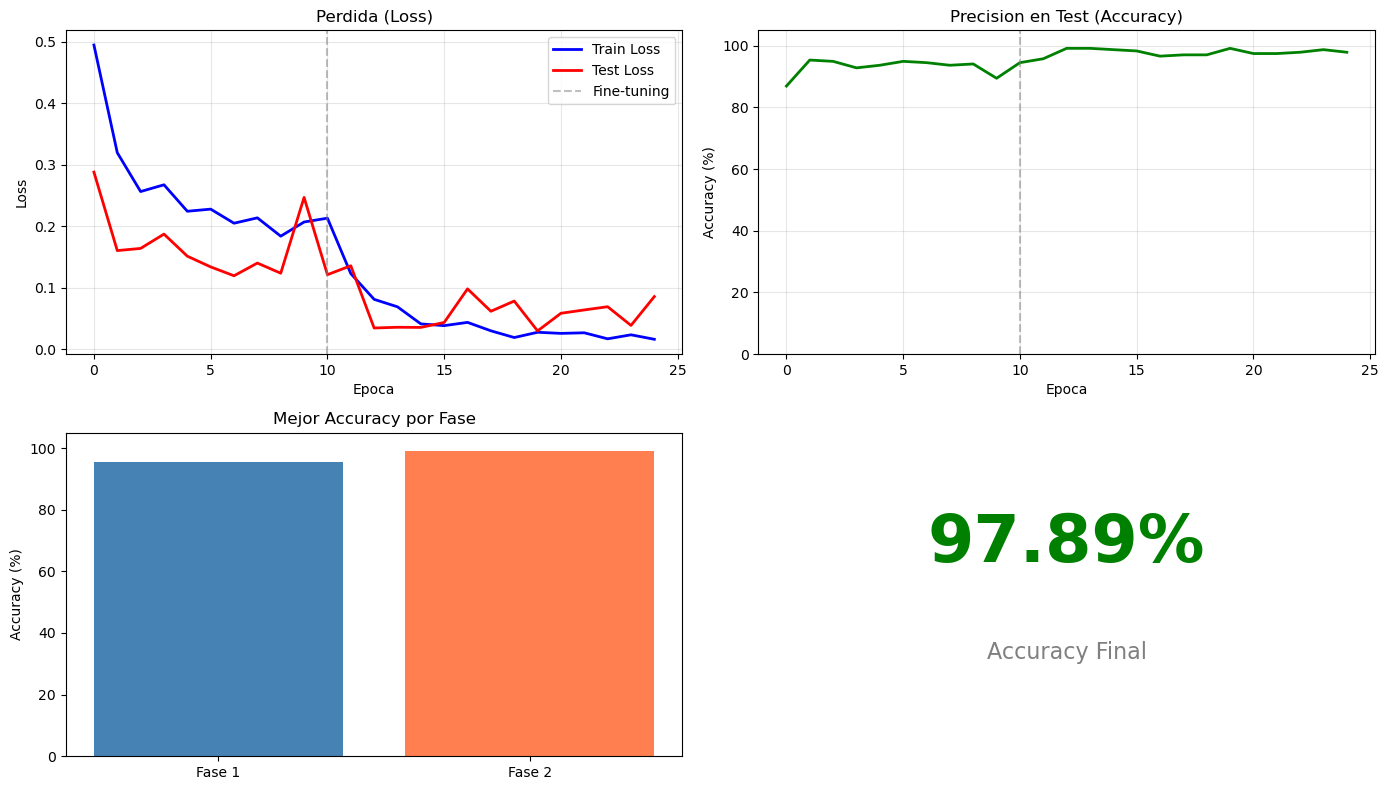

In [8]:
# ---
# 8. GRAFICA DE EVOLUCION DEL ENTRENAMIENTO
# ---
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 8))

sep = len(historial1['train_loss'])  # Punto de separacion entre fases

# Loss
ax1.plot(historial['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(historial['test_loss'], 'r-', label='Test Loss', linewidth=2)
ax1.axvline(x=sep, color='gray', linestyle='--', alpha=0.5, label='Fine-tuning')
ax1.set_title('Perdida (Loss)')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(historial['test_acc'], 'g-', linewidth=2)
ax2.axvline(x=sep, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Precision en Test (Accuracy)')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)

# Comparacion antes/despues
ax3.bar(['Fase 1', 'Fase 2'],
        [max(historial1['test_acc']), max(historial2['test_acc'])],
        color=['steelblue', 'coral'])
ax3.set_title('Mejor Accuracy por Fase')
ax3.set_ylabel('Accuracy (%)')
ax3.set_ylim(0, 105)

# Ultimo accuracy
ax4.text(0.5, 0.6, '{:.2f}%'.format(historial['test_acc'][-1]),
         fontsize=48, ha='center', fontweight='bold', color='green')
ax4.text(0.5, 0.3, 'Accuracy Final',
         fontsize=16, ha='center', color='gray')
ax4.axis('off')

plt.tight_layout()
plt.show()

---
## 11. Evaluacion Detallada

### Matriz de Confusion
Muestra cuantos aciertos y errores tuvo el modelo en cada clase.

### Curva ROC
La curva ROC muestra la relacion entre:
- **TPR** (True Positive Rate): que tan bien detecta Kuromi.
- **FPR** (False Positive Rate): que tan seguido confunde Cinnamoroll como Kuromi.

Un AUC (Area Under Curve) cercano a 1.0 indica un clasificador perfecto.


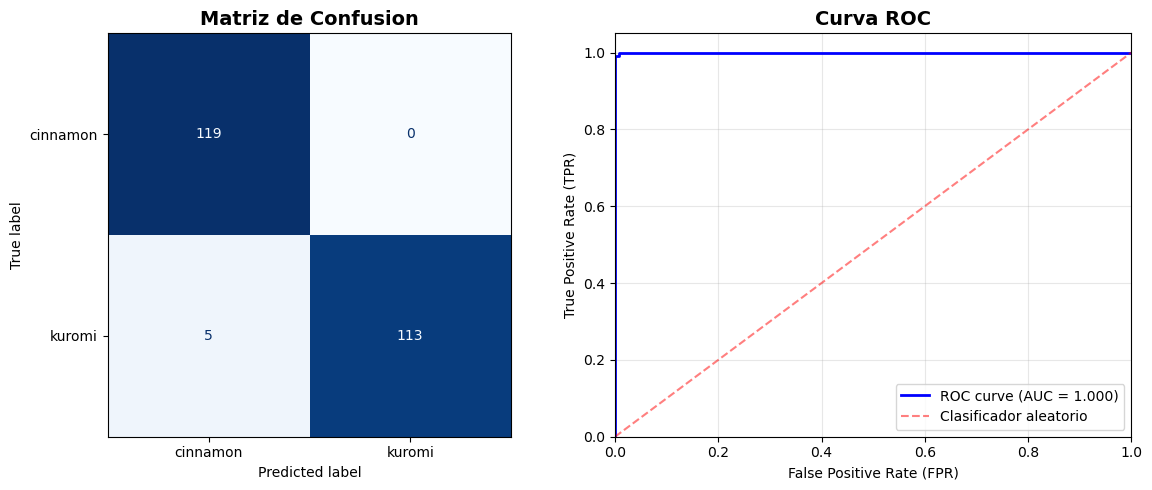

=== Metricas de Evaluacion ===
  Accuracy:  97.89%
  Precision: 100.00%
  Recall:    95.76%
  F1-Score:  97.84%
  AUC-ROC:   1.000

Clase negativa (0): cinnamon
Clase positiva (1): kuromi


In [9]:
# ---
# 9. MATRIZ DE CONFUSION Y CURVA ROC
# ---
def evaluar_biclase(modelo, test_loader, device, clases):
    '''
    Evalua el modelo y muestra matriz de confusion y curva ROC.

    Args:
        modelo: Modelo entrenado.
        test_loader: DataLoader de prueba.
        device: CPU/GPU.
        clases: Lista con nombres de clases [negativa, positiva].
    '''
    modelo.eval()
    todas_reales = []
    todas_predichas = []
    todas_probabilidades = []

    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes = imagenes.to(device)
            outputs = modelo(imagenes)
            probabilidades = torch.softmax(outputs, dim=1)
            _, predichas = torch.max(outputs, 1)

            todas_reales.extend(etiquetas.cpu().numpy())
            todas_predichas.extend(predichas.cpu().numpy())
            todas_probabilidades.extend(probabilidades[:, 1].cpu().numpy())  # Prob clase 1

    # ---- Matriz de confusion ----
    cm = confusion_matrix(todas_reales, todas_predichas)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax1, cmap='Blues', colorbar=False, values_format='d')
    ax1.set_title('Matriz de Confusion', fontsize=14, fontweight='bold')

    # ---- Curva ROC ----
    fpr, tpr, _ = roc_curve(todas_reales, todas_probabilidades)
    roc_auc = auc(fpr, tpr)

    ax2.plot(fpr, tpr, 'b-', linewidth=2,
             label='ROC curve (AUC = {:.3f})'.format(roc_auc))
    ax2.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Clasificador aleatorio')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate (FPR)')
    ax2.set_ylabel('True Positive Rate (TPR)')
    ax2.set_title('Curva ROC', fontsize=14, fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ---- Metricas ----
    accuracy = 100.0 * (cm[0, 0] + cm[1, 1]) / cm.sum()
    precision = 100.0 * cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0
    recall = 100.0 * cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print('=== Metricas de Evaluacion ===')
    print('  Accuracy:  {:.2f}%'.format(accuracy))
    print('  Precision: {:.2f}%'.format(precision))
    print('  Recall:    {:.2f}%'.format(recall))
    print('  F1-Score:  {:.2f}%'.format(f1))
    print('  AUC-ROC:   {:.3f}'.format(roc_auc))
    print('')
    print('Clase negativa (0): ' + clases[0])
    print('Clase positiva (1): ' + clases[1])


evaluar_biclase(model, test_loader, device, clases)

---
### ?Que significan estas metricas?

**Accuracy** no siempre es suficiente. En clasificacion binaria importa mas:

| Metrica | Que mide | Cuando importa |
|---------|----------|----------------|
| **Precision** | De las que predije como clase X, ?cuantas eran realmente X? | Evitar falsos positivos |
| **Recall** | De las que eran clase X, ?cuantas capture? | Evitar falsos negativos |
| **F1-Score** | Balance entre Precision y Recall | Clases desbalanceadas |
| **AUC-ROC** | ?Que tan bien separa el modelo ambas clases? | Independiente del umbral |

En **multiclase** (10 digitos de MNIST) estas metricas se promedian por clase
(macro, micro, weighted). En **binario** son mas intuitivas porque tenemos
"positivo" y "negativo" claros.

> **Dato curioso:** En este proyecto, la "clase positiva" es Cinnamoroll.
> Precision = ?de las que dije Cinnamoroll, cuantas eran Cinnamoroll?
> Recall = ?de todos los Cinnamoroll en test, cuantas atrape?


---
## 12. Evaluacion Visual: Predicciones en Test

Vamos a ver visualmente que tan bien (o mal) clasifica el modelo.


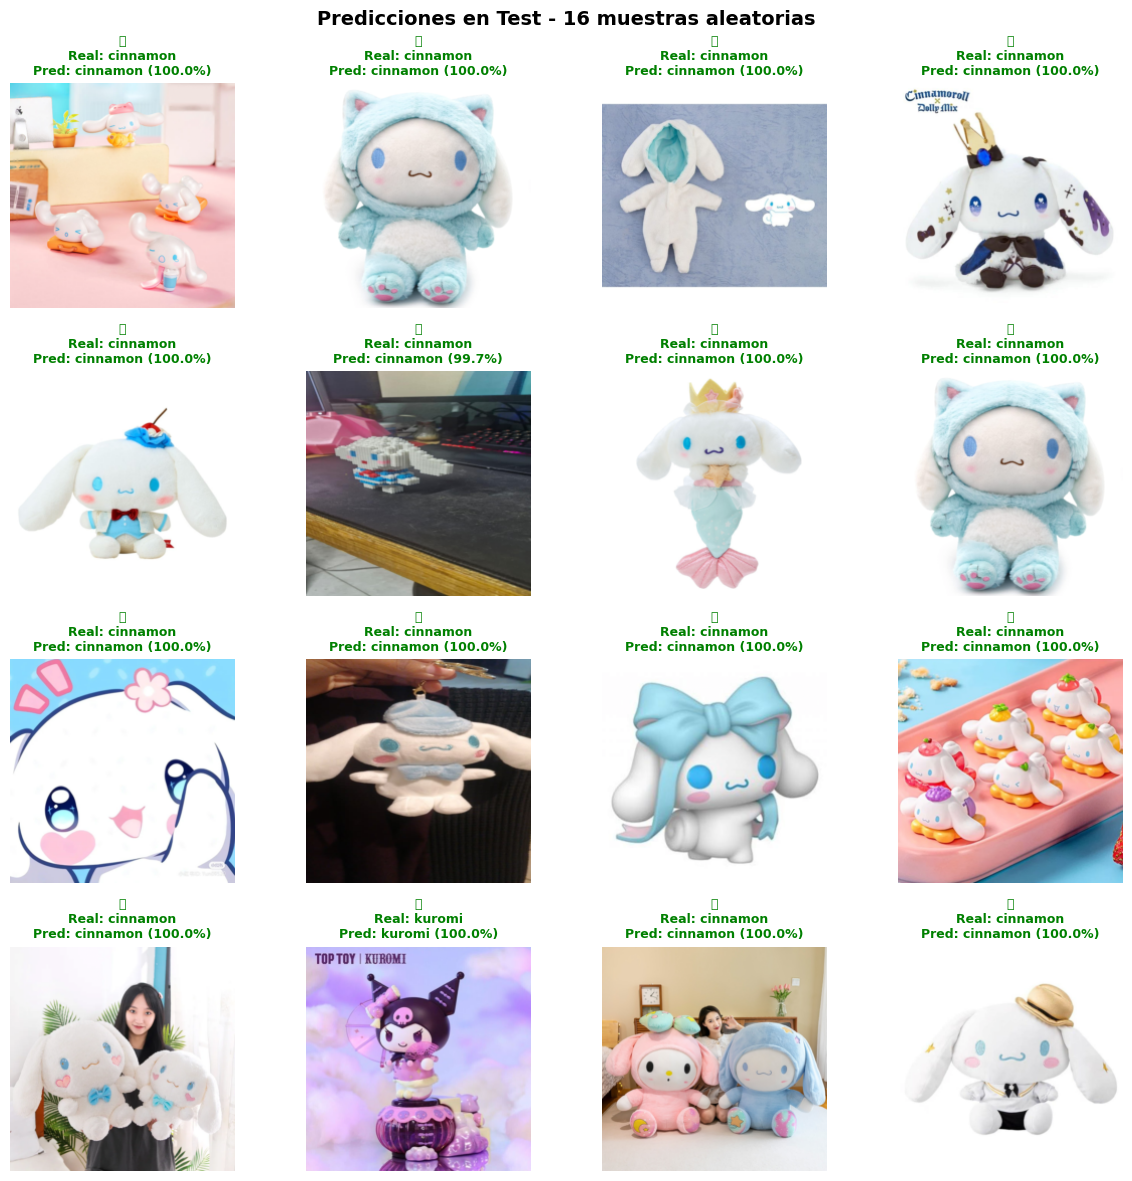

In [10]:
# ---
# 12a. GRILLA DE PREDICCIONES EN TEST
# ---
import math
import random

model.eval()
todas_reales = []
todas_predichas = []
todas_probabilidades = []
imagenes_guardadas = []

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        salidas = model(imagenes)
        probabilidades = torch.softmax(salidas, dim=1)
        _, predichas = torch.max(salidas, 1)
        todas_reales.extend(etiquetas.cpu().numpy())
        todas_predichas.extend(predichas.cpu().numpy())
        todas_probabilidades.extend(probabilidades[:, 1].cpu().numpy())
        # Guardar primeras imagenes para visualizar
        if len(imagenes_guardadas) < 128:
            for i in range(len(imagenes)):
                if len(imagenes_guardadas) < 128:
                    imagenes_guardadas.append((
                        imagenes[i].cpu(), etiquetas[i].item(),
                        predichas[i].item(), probabilidades[i, 1].item()
                    ))

# Mostrar 16 aleatorias
n = 16
idx = random.sample(range(len(imagenes_guardadas)), n)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img, real, pred, prob = imagenes_guardadas[idx[i]]
    # Desnormalizar
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) +           torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())
    acierto = real == pred
    color = 'green' if acierto else 'red'
    etiqueta = '{}\nReal: {}\nPred: {} ({:.1f}%)'.format(
        '✅' if acierto else '❌',
        clases[real], clases[pred], prob * 100 if pred == 1 else (1 - prob) * 100)
    ax.set_title(etiqueta, fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predicciones en Test - 16 muestras aleatorias',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Analisis de Errores

Veamos que imagenes el modelo clasifico MAL. Esto ayuda a entender
sus debilidades (fondos dificiles, angulos raros, iluminacion).


In [11]:
# ---
# 13a. GRILLA DE ERRORES (solo las que fallo)
# ---
errores = [(img, real, pred, prob) for (img, real, pred, prob) in imagenes_guardadas
           if real != pred]

if len(errores) == 0:
    print('\n🎉 No hubo errores en las 128 muestras guardadas!')
else:
    n_mostrar = min(len(errores), 12)
    cols = 4
    rows = math.ceil(n_mostrar / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten() if n_mostrar > 1 else [axes]

    for i in range(n_mostrar):
        img, real, pred, prob = errores[i]
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) +               torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].set_title('Real: {}\nPred: {} ({:.1f}%)'.format(
            clases[real], clases[pred],
            prob * 100 if pred == 1 else (1 - prob) * 100),
            fontsize=9, color='red')
        axes[i].axis('off')

    for i in range(n_mostrar, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Errores del Modelo en Test ({} errores de 128 muestras)'.format(
        len(errores)), fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nTasa de error en estas 128 muestras: {:.1f}%'.format(
        len(errores) / len(imagenes_guardadas) * 100))


🎉 No hubo errores en las 128 muestras guardadas!


---
## 14. Probar el Modelo con tus Propias Fotos

Ahora vamos a probar el clasificador con imagenes nuevas que NO estuvieron en el dataset de entrenamiento.

Puedes:
- **Op A**: Subir una foto de una figura (funciona en Colab y VSCode).
- **Op B**: Usar el explorador de archivos local (VSCode).


In [12]:
# ---
# 10. FUNCION DE PREDICCION PARA IMAGENES NUEVAS
# ---
def predecir_figura(ruta_imagen, modelo, device, clases, top=2):
    '''
    Predice si una imagen es Kuromi o Cinnamoroll y muestra el resultado.

    Args:
        ruta_imagen: Ruta al archivo de imagen o PIL.Image.
        modelo: Modelo entrenado.
        device: CPU/GPU.
        clases: Lista de nombres de clases.
        top: Mostrar las top N predicciones (default 2).

    Returns:
        tuple: (clase_predicha, confianza)
    '''
    modelo.eval()

    # Cargar imagen
    if isinstance(ruta_imagen, str):
        imagen = Image.open(ruta_imagen).convert('RGB')
    else:
        imagen = ruta_imagen.convert('RGB')

    # Preprocesar
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    tensor = transform(imagen).unsqueeze(0).to(device)

    # Predecir
    with torch.no_grad():
        outputs = modelo(tensor)
        probabilidades = torch.softmax(outputs, dim=1)[0]

    # Obtener top predicciones
    prob_np = probabilidades.cpu().numpy()
    indices_top = np.argsort(prob_np)[::-1][:top]

    # ---- Visualizar ----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

    ax1.imshow(imagen)
    ax1.axis('off')

    # Resultado principal
    pred_idx = indices_top[0]
    pred_clase = clases[pred_idx]
    confianza = prob_np[pred_idx] * 100
    color = 'green' if confianza > 70 else 'orange'

    ax1.set_title('Prediccion: {}\nConfianza: {:.1f}%'.format(pred_clase, confianza),
                  fontsize=14, fontweight='bold', color=color)

    # Barras de probabilidad
    colores = ['steelblue'] * len(clases)
    colores[pred_idx] = 'crimson'
    ax2.barh(clases, prob_np, color=colores, edgecolor='gray')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probabilidad')
    ax2.set_title('Distribucion de probabilidad')
    ax2.grid(axis='x', alpha=0.3)

    for i, v in enumerate(prob_np):
        ax2.text(v + 0.01, i, '{:.1%}'.format(v), va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return pred_clase, confianza

---
## 15. Probar el Modelo

Selecciona una imagen de una figura de Kuromi o Cinnamoroll para ver que predice el modelo.


In [13]:
# ---
# 11a. PREDECIR CON IMAGEN SUBIDA (Colab)
# ---
if EN_COLAB:
    print('Sube una foto de una figura de Kuromi o Cinnamoroll...')
    archivos = files.upload()
    if archivos:
        nombre = list(archivos.keys())[0]
        img = Image.open(io.BytesIO(archivos[nombre]))
        predecir_figura(img, model, device, clases)
    else:
        print('No se subio ninguna imagen.')
else:
    print('Usa la siguiente celda para VSCode.')

Usa la siguiente celda para VSCode.


In [14]:
# ---
# 11b. PREDECIR CON IMAGEN LOCAL (VSCode)
# ---
if not EN_COLAB:
    from tkinter import filedialog, Tk
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    ruta = filedialog.askopenfilename(
        title='Selecciona una foto de Kuromi o Cinnamoroll',
        filetypes=[('Imagenes', '*.png *.jpg *.jpeg *.bmp')]
    )

    if ruta:
        resultado, confianza = predecir_figura(ruta, model, device, clases)
        print('Resultado: {} (Confianza: {:.1f}%)'.format(resultado, confianza))
    else:
        print('No se selecciono ninguna imagen.')
else:
    print('Usa la celda anterior (Colab).')

---
## 16. Guardar el Modelo Entrenado

El modelo se guarda en formato PyTorch (.pth). Para cargarlo despues:

```python
# Al cargar, debemos crear la misma arquitectura
modelo = crear_modelo_transfer_learning(num_clases=2, congelar=False)
modelo.load_state_dict(torch.load('modelos/modelo_final.pth'))
modelo.eval()
```

**Nota importante**: Al cargar, `congelar=False` para que todas las capas tengan `requires_grad=True` y el `state_dict` coincida.


In [ ]:
# ---
# 13. GUARDAR MODELO ENTRENADO (CON VERSIONADO)
# ---
import json
from datetime import datetime

timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Version con timestamp
ruta_modelo_vers = os.path.join(RUTA_MODELOS, 'modelo_{}.pth'.format(timestamp))
torch.save(model.state_dict(), ruta_modelo_vers)

# Version sin timestamp (siempre sobrescribe, facil de cargar)
ruta_modelo_final = os.path.join(RUTA_MODELOS, 'modelo_final.pth')
torch.save(model.state_dict(), ruta_modelo_final)

tamano_kb = os.path.getsize(ruta_modelo_final) / 1024.0
print('Modelo versionado: ' + ruta_modelo_vers)
print('Modelo final: ' + ruta_modelo_final)
print('Tamano: {:.1f} KB'.format(tamano_kb))

# Guardar mapeo de clases
with open(os.path.join(RUTA_MODELOS, 'clases.json'), 'w') as f:
    json.dump({
        'classes': clases,
        'class_to_idx': train_dataset.class_to_idx,
        'fecha': timestamp,
        'autora': AUTORA
    }, f, indent=2)
print('Mapeo de clases guardado.')

# Guardar log de entrenamiento como CSV
import csv
ruta_log = os.path.join(RUTA_MODELOS, 'log_entrenamiento_{}.csv'.format(timestamp))
with open(ruta_log, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'test_loss', 'test_acc'])
    for i in range(len(historial['train_loss'])):
        writer.writerow([
            i+1,
            '{:.4f}'.format(historial['train_loss'][i]),
            '{:.4f}'.format(historial['test_loss'][i]),
            '{:.2f}'.format(historial['test_acc'][i])
        ])
print('Log de entrenamiento: ' + ruta_log)

---
## 17. Como Mejorar el Modelo

### Agregar mas imagenes

1. Toma fotos de tus figuras desde diferentes angulos y fondos.
2. Colocalas en las carpetas correspondientes:
   - `dataset/train/kuromi/` para Kuromi.
   - `dataset/train/cinnamon/` para Cinnamoroll.
3. Si quieres probar, pon algunas en `dataset/test/`.
4. Vuelve a ejecutar el notebook desde la Seccion 2.

### Usar el scraping incluido

Ejecuta el script de scraping incluido en la carpeta `scraping/`:

```bash
python scraping/scraping_imagenes.py
```

Esto descargara ~150 imagenes por clase de Google Images.

### Probar otros modelos
Si ResNet18 no da suficiente precision, puedes probar con:
- **ResNet50**: mas profundo, mayor precision, mas lento.
- **EfficientNet-B0**: mejor relacion precision/velocidad.
- **Vision Transformer (ViT)**: arquitectura moderna basada en transformers.


In [ ]:
# ---
# 14. FOOTER DE AUTORIA Y RENDIMIENTO
# ---
import time, psutil, platform

fin = time.time()
segundos = fin - INICIO
mm, ss = divmod(int(segundos), 60)

print("")
print("=" * 55)
print("  Hecho con 💜 por " + AUTORA)
print("  Diplomado RNA - Modulo 4: Deep Learning")
print("  UAEM")
print("")
print("  Especificaciones del equipo:")
cpu = platform.processor() or "AMD Ryzen 5 3600"
print("     CPU: " + cpu)
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"
gpu_mem = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if torch.cuda.is_available() else 0
print("     GPU: " + gpu_name + " (" + str(gpu_mem) + " GB)")
ram = round(psutil.virtual_memory().total / 1e9, 1)
print("     RAM: " + str(ram) + " GB")
print("     PyTorch " + torch.__version__ + " + CUDA " + (torch.version.cuda or "N/A"))
print("")
print("  Tiempo total de ejecucion: " + str(mm) + " min " + str(ss) + " seg")
print("  Mejor accuracy en test: " + "{:.2f}%".format(max(historial['test_acc'])))
print("  Hiperparametros: batch_size={}, lr_fase1={}, lr_fase2={}, epochs={}+{}".format(
    CONFIG['BATCH_SIZE'], CONFIG['LR_FASE1'], CONFIG['LR_FASE2'],
    CONFIG['EPOCHS_FASE1'], CONFIG['EPOCHS_FASE2']))
# AUC-ROC se calcula en la celda de evaluacion
print("  Fecha: " + time.strftime('%Y-%m-%d %H:%M'))
print("=" * 55)


---
## Referencias

- [ResNet: Deep Residual Learning](https://arxiv.org/abs/1512.03385) - Articulo original de ResNet
- [ResNet18 en PyTorch](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) - Documentacion oficial
- [Transfer Learning tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) - Tutorial oficial de PyTorch
- [Sanrio Wiki - Kuromi](https://sanrio.fandom.com/wiki/Kuromi) - Informacion del personaje
- [Sanrio Wiki - Cinnamoroll](https://sanrio.fandom.com/wiki/Cinnamoroll) - Informacion del personaje
- [Repositorio del proyecto](https://github.com/MorritaConP1to/Diplomado-RNA) - Codigo completo del diplomado
